# Tree Interpretation

This notebook loads the winning post-pruned tree and inspects its feature importances and split usage.

## Planned Steps

- Load the encoded training set
- Fit the winning tree with `random_state=42` and `ccp_alpha=0.000890`
- Print the top 10 feature importances
- Print the cumulative importance of the top 5 features
- Print how many split nodes use each feature

In [1]:
from pathlib import Path

import pandas as pd
from sklearn.tree import DecisionTreeClassifier

TRAIN_PATH = Path('data/processed/encoded_train.csv')
if not TRAIN_PATH.exists():
    TRAIN_PATH = Path('../data/processed/encoded_train.csv')

train_df = pd.read_csv(TRAIN_PATH)
X_train = train_df.drop(columns=['Approval'])
y_train = train_df['Approval']

winning_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=0.000890)
winning_tree.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': winning_tree.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

top10 = importance_df.head(10)
print('Top 10 feature importances')
print(top10.to_string(index=False))

top5_cumulative = top10.head(5)['importance'].sum()
print(f"\nCumulative importance of top 5: {top5_cumulative:.4f}")

split_feature_indices = winning_tree.tree_.feature
split_feature_indices = split_feature_indices[split_feature_indices >= 0]
split_counts = pd.Series(split_feature_indices).value_counts().sort_index()
split_count_df = pd.DataFrame({
    'feature': X_train.columns[split_counts.index],
    'split_nodes': split_counts.values,
}).sort_values(['split_nodes', 'feature'], ascending=[False, True]).reset_index(drop=True)

print('\nSplit-node counts by feature')
print(split_count_df.to_string(index=False))


Top 10 feature importances
             feature  importance
         CreditScore    0.598547
   DebtToIncomeRatio    0.257433
        AnnualIncome    0.050931
        PriorDefault    0.040312
RevolvingUtilization    0.034648
 CreditHistoryMonths    0.009731
BankruptcyLast7Years    0.004633
                 Age    0.003765
      IncomeVerified    0.000000
            Employed    0.000000

Cumulative importance of top 5: 0.9819

Split-node counts by feature
             feature  split_nodes
   DebtToIncomeRatio            6
        AnnualIncome            5
         CreditScore            4
RevolvingUtilization            4
        PriorDefault            3
 CreditHistoryMonths            2
                 Age            1
BankruptcyLast7Years            1


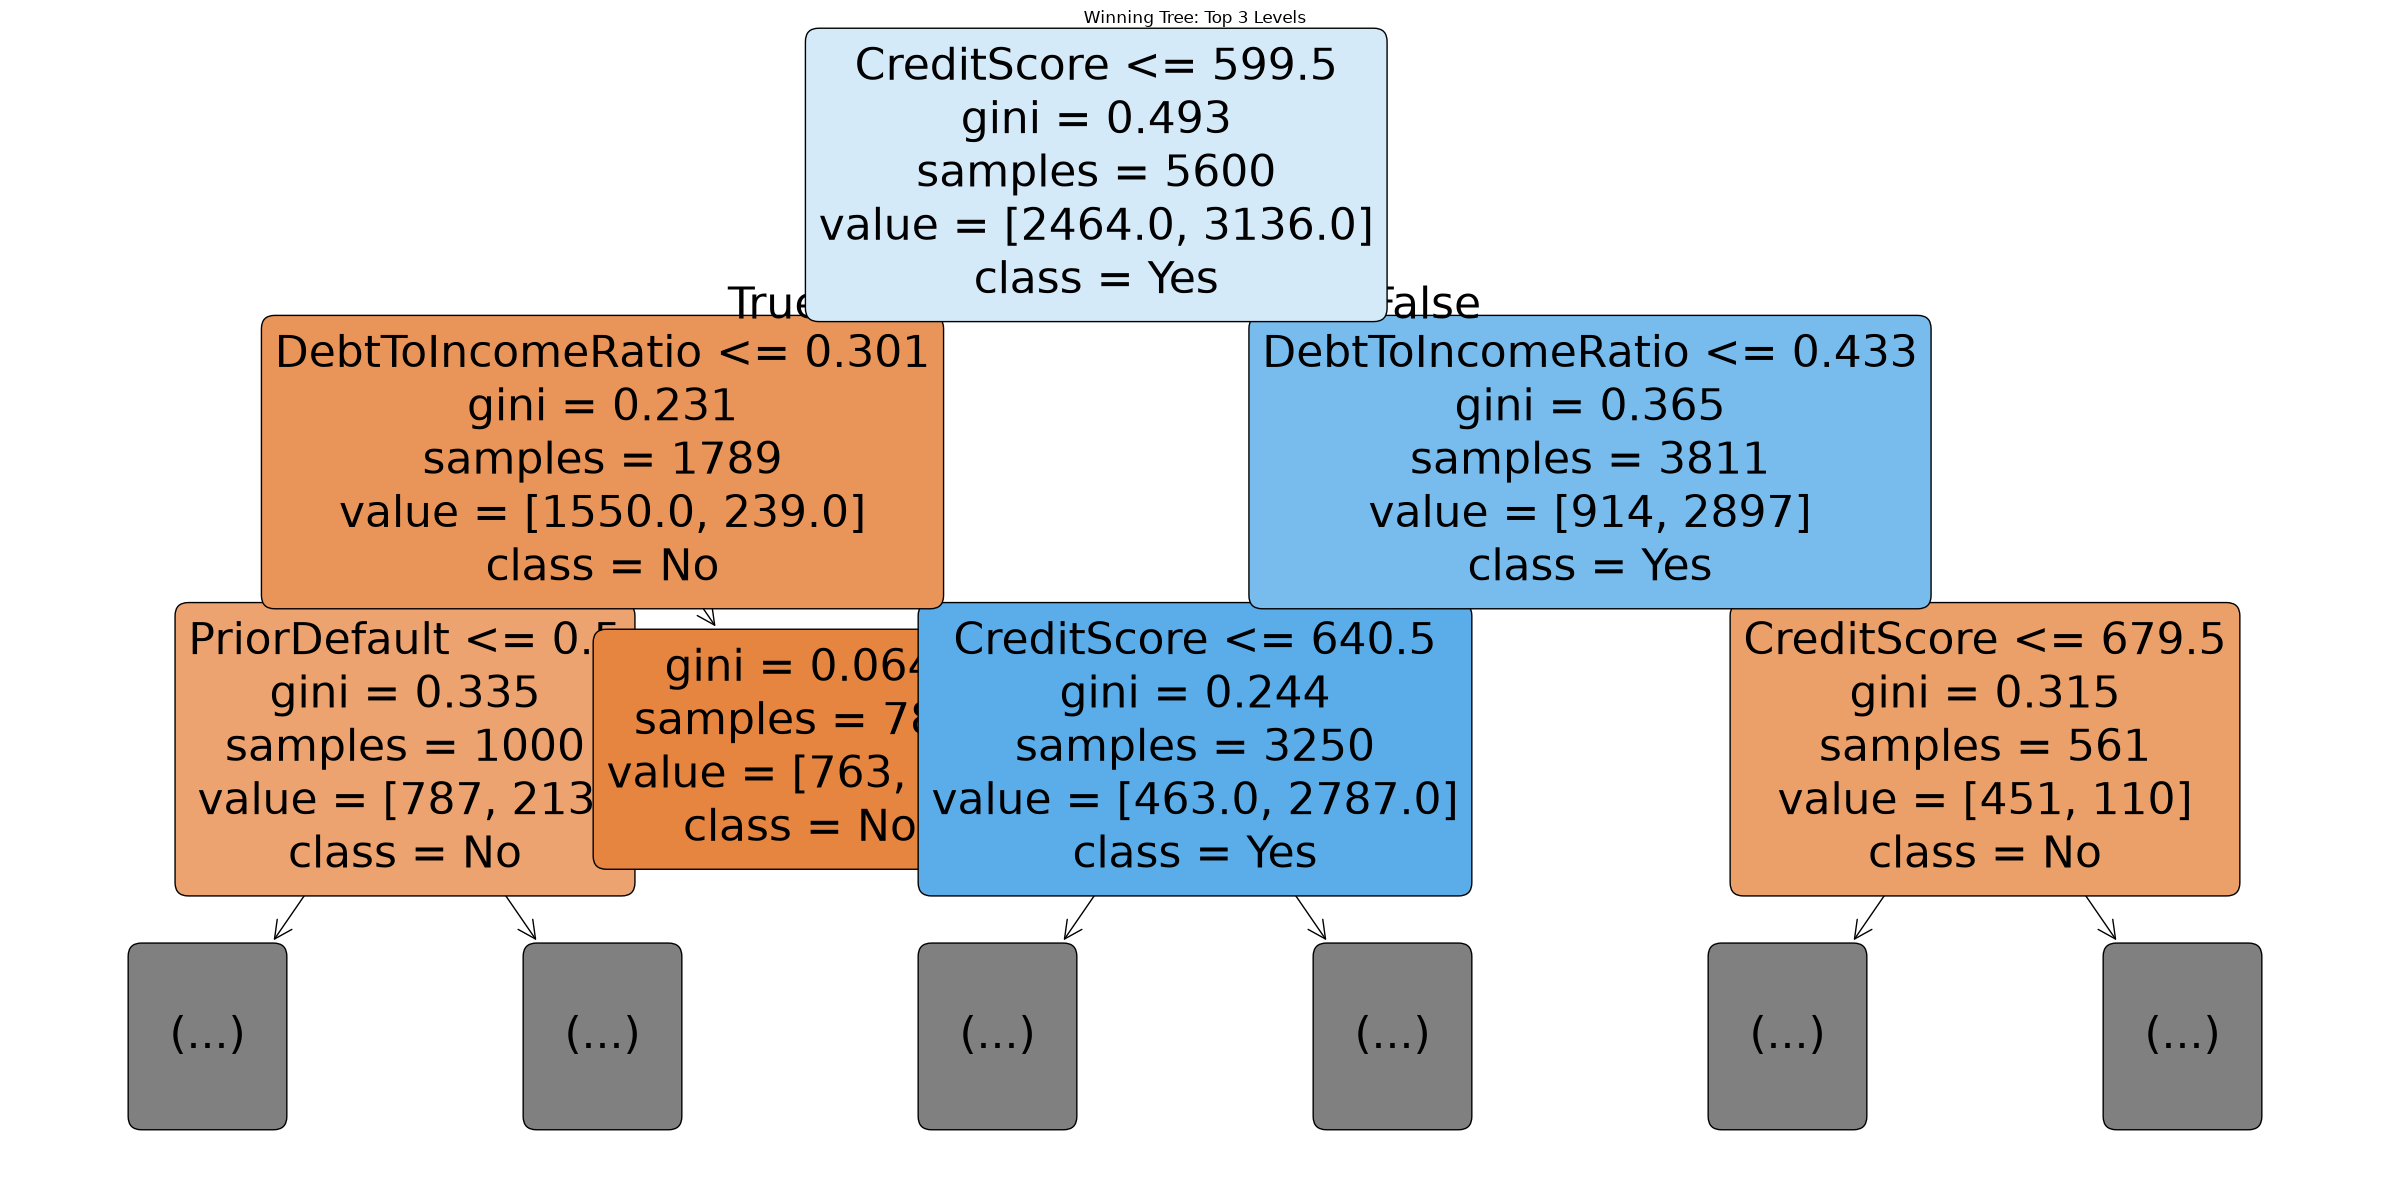

In [2]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))
plot_tree(
    winning_tree,
    feature_names=X_train.columns,
    class_names=winning_tree.classes_,
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=32,
)
plt.title('Winning Tree: Top 3 Levels')
plt.tight_layout()
plt.show()
